# Meta 2 ECAC - Testing Feature Selection Methods

In [39]:
# Importation of all Frameworks and Tools needed
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.model_selection import train_test_split, LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix
from imblearn.over_sampling import SMOTE
from scipy import stats
from scipy.stats import skew, kurtosis, iqr
from scipy.signal import welch
from scipy.fft import rfft, rfftfreq


Importing Feature Dataset obtained in meta1

In [40]:
# Importing the dataset and filtering activities
df = pd.read_csv('feature_set.csv')
df_filtered = df[df["Activity"].isin(range(1, 8))].copy()
print(f"Filtered dataset shape: {df_filtered.shape}")
print(f"Unique activities after filtering: {df_filtered['Activity'].unique()}")


Filtered dataset shape: (1405, 179)
Unique activities after filtering: [1 2 3 4 5 6 7]


Repeating the same feature extraction principals from first meta 

In [41]:
def dominant_frequency(signal, fs):
    n = len(signal)
    if n == 0: return 0
    yf = np.abs(rfft(signal))
    xf = rfftfreq(n, d=1/fs)
    dominant_idx = np.argmax(yf[1:]) + 1 
    return xf[dominant_idx]

def spectral_entropy(signal, fs):
    freqs, psd = welch(signal, fs=fs)
    psd_sum = np.sum(psd)
    if psd_sum == 0: return 0
    psd_norm = psd / psd_sum
    entropy = -np.sum(psd_norm * np.log2(psd_norm + 1e-12))
    return entropy

def zero_crossing_rate(signal):
    return np.sum(np.diff(np.sign(signal)) != 0) / len(signal)

def mean_crossing_rate(signal):
    mean_val = np.mean(signal)
    centered = signal - mean_val
    return np.sum(np.diff(np.sign(centered)) != 0) / len(signal)

# Physical Features Helpers
def compute_cagh(acc):
    gravity = np.mean(acc, axis=0)
    if np.std(acc.flatten()) == 0 or np.std(np.tile(gravity, acc.shape[0])) == 0: return 0
    corr = np.corrcoef(acc.flatten(), np.tile(gravity, acc.shape[0]))[0, 1]
    return corr

def compute_avg(acc):
    gravity = np.mean(acc, axis=0)
    return np.linalg.norm(gravity)

def compute_avh(gyro, bins=5):
    magnitudes = np.linalg.norm(gyro, axis=1)
    hist, _ = np.histogram(magnitudes, bins=bins, range=(0, np.max(magnitudes) + 1e-6))
    return hist.tolist()

def compute_aratg(gyro, acc):
    gravity = np.mean(acc, axis=0)
    norm_g = np.linalg.norm(gravity)
    if norm_g == 0: return 0
    gravity_unit = gravity / norm_g
    projected = np.dot(gyro, gravity_unit)
    return np.mean(np.abs(projected))

def extract_statistical_features(signal, fs):
    return [
        np.mean(signal), np.median(signal), np.std(signal), np.var(signal),
        np.sqrt(np.mean(signal**2)), np.mean(np.diff(signal)),
        skew(signal), kurtosis(signal), iqr(signal),
        zero_crossing_rate(signal), mean_crossing_rate(signal),
        spectral_entropy(signal, fs),
    ]

def extract_correlations(window):
    features = []
    axes = window.shape[1]
    for i in range(axes):
        for j in range(i + 1, axes):
            # Add small epsilon to avoid div by zero
            if np.std(window[:, i]) == 0 or np.std(window[:, j]) == 0:
                features.append(0)
            else:
                features.append(np.corrcoef(window[:, i], window[:, j])[0, 1])
    return features

def extract_physical_features(window, fs):
    acc = window[:, :3]
    gyro = window[:, 3:6]
    
    mi = np.linalg.norm(acc, axis=1)
    ai = np.mean(mi)
    vi = np.var(mi)
    sma = np.sum(np.abs(acc)) / len(acc)
    
    cov = np.cov(acc.T)
    if cov.ndim == 2:
        eva = np.linalg.eigvalsh(cov)[-2:]
    else:
        eva = [0, 0]

    def energy(signal): return np.sum(signal**2) / len(signal)
    df = [dominant_frequency(signal, fs) for signal in window.T]
    en = [energy(signal) for signal in window.T]
    aae = np.mean(en[:3])
    are = np.mean(en[3:6])
    ame = np.mean(en[6:9])

    cagh = compute_cagh(acc)
    avg = compute_avg(acc)
    avh = compute_avh(gyro)
    aratg = compute_aratg(gyro, acc)

    return [ai, vi, sma] + list(eva) + df + en + [aae, are, ame, cagh, avg, aratg] + avh

def extract_feature_vector(window, fs):
    features = []
    # Statistical (9 axes)
    for i in range(window.shape[1]):
        features.extend(extract_statistical_features(window[:, i], fs))
    # Correlations
    features.extend(extract_correlations(window))
    # Physical
    features.extend(extract_physical_features(window, fs))
    return np.array(features)

def sliding_windows(data, labels, window_sec=5, overlap=0.5, fs=50):
    window_size = int(window_sec * fs)
    # Safety Check: Ensure window_size is at least 1
    if window_size < 1: 
        window_size = 1
        
    step_size = int(window_size * (1 - overlap))
    # Safety Check: Ensure step_size is at least 1 to prevent ValueError
    if step_size < 1: 
        step_size = 1
    
    print(f"  > Segmentation: fs={fs:.1f}Hz, window={window_size}, step={step_size}")

    for start in range(0, len(data) - window_size + 1, step_size):
        end = start + window_size
        window = data[start:end]
        label_segment = labels[start:end]
        # Filter: Only keep window if activity is consistent
        if np.all(label_segment == label_segment[0]):
            yield window, label_segment[0]

Importing the Raw dataset (so we can have access to each participant activity)

In [42]:
def load_participant_3():
    # Helper to load raw data for Participant 3
    df_list = []
    part = 3
    print(f"Loading data for Participant {part}...")
    for device in range(1, 6): # Devices 1 to 5
        url = f"https://raw.githubusercontent.com/spl-icsforth/FORTH_TRACE_DATASET/master/part{part}/part{part}dev{device}.csv"
        try:
            # Columns based on FORTH-TRACE documentation
            cols = ["DeviceId", "Acc_x", "Acc_y", "Acc_z", 
                    "Gyro_x", "Gyro_y", "Gyro_z", 
                    "Mag_x", "Mag_y", "Mag_z", 
                    "Timestamp", "Activity"]
            temp_df = pd.read_csv(url, header=None, names=cols)
            df_list.append(temp_df)
            print(f"  - Loaded Device {device}")
        except Exception as e:
            print(f"  - Error loading Device {device}: {e}")
            
    return pd.concat(df_list, axis=0, ignore_index=True)

def generate_features_for_participant(df):
    print("Extracting features (this may take a moment)...")
    
    # --- FIXED SAMPLING RATE ESTIMATION ---
    # Calculate median difference to avoid outliers from file concatenation
    diffs = df["Timestamp"].diff()
    avg_diff = diffs[diffs > 0].median() # Ignore 0 or negative jumps
    
    # Check if units are milliseconds
    if avg_diff > 1: 
        print(f"  - Detected timestamps in Milliseconds (avg diff ~{avg_diff:.1f})")
        fs = 1000.0 / avg_diff
    elif avg_diff > 0:
        print(f"  - Detected timestamps in Seconds (avg diff ~{avg_diff:.4f})")
        fs = 1.0 / avg_diff
    else:
        print("  - Could not detect time diff, defaulting to 50Hz")
        fs = 50.0
        
    print(f"  - Estimated Sampling Rate: {fs:.2f} Hz")
    # --------------------------------------
    
    data_cols = ["Acc_x","Acc_y","Acc_z","Gyro_x","Gyro_y","Gyro_z","Mag_x","Mag_y","Mag_z"]
    data = df[data_cols].values
    labels = df["Activity"].values
    
    X_list = []
    y_list = []
    
    count = 0
    for window, label in sliding_windows(data, labels, fs=fs):
        feat = extract_feature_vector(window, fs)
        X_list.append(feat)
        y_list.append(label)
        count += 1
        
    print(f"  - Extracted {count} windows.")
    
    if count == 0:
        print("WARNING: No windows extracted. Check your data or window parameters.")
        return pd.DataFrame()

    X = np.array(X_list)
    y = np.array(y_list)
    
    feat_cols = [f"Feature_{i}" for i in range(X.shape[1])]
    df_feats = pd.DataFrame(X, columns=feat_cols)
    df_feats["Activity"] = y
    
    # Drop rows with NaNs (e.g. from Skew/Kurtosis on flat signals)
    df_feats = df_feats.dropna()
    
    return df_feats

Checking whether the dataset is balanced or not 

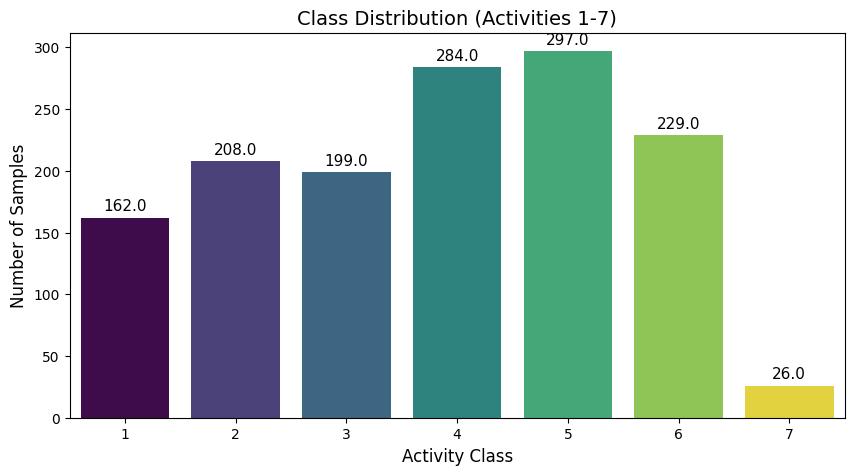


--- Exact Counts per Activity ---
Activity
1    162
2    208
3    199
4    284
5    297
6    229
7     26
Name: count, dtype: int64

Imbalance Ratio (Max/Min): 11.42


In [43]:
# Extract Labels (y)
y = df_filtered['Activity'].values
# Visualize Class Distribution
plt.figure(figsize=(10, 5))
# Use seaborn to plot count of each activity
ax = sns.countplot(x=y, hue=y,  palette="viridis" , legend=False)
plt.title('Class Distribution (Activities 1-7)', fontsize=14)
plt.xlabel('Activity Class', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='baseline', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')
plt.show()
# Numerical Summary
print("\n--- Exact Counts per Activity ---")
print(df_filtered['Activity'].value_counts().sort_index())

# Check for Imbalance
counts = df_filtered['Activity'].value_counts()
min_count = counts.min()
max_count = counts.max()
imbalance_ratio = max_count / min_count

print(f"\nImbalance Ratio (Max/Min): {imbalance_ratio:.2f}")

1.2 Defining a SMOTE Function

In [44]:
def generate_synthetic_samples(X, y, target_activity, n_new_samples=3):
    """
    Generates n_new_samples for the target_activity using SMOTE.
    Returns the original data + the new synthetic samples.
    """
    print(f"Generating {n_new_samples} synthetic samples for Activity {target_activity}...")
    
    # Count current samples
    current_count = np.sum(y == target_activity)
    if current_count < 2:
        print("Error: Not enough samples to use SMOTE.")
        return None, None
        
    # Define strategy: Dictionary with {label: n_final_samples}
    # We only want to oversample the target_activity
    strategy = {target_activity: current_count + n_new_samples}
    
    # K-neighbors must be less than n_samples
    k = min(current_count - 1, 5)
    
    # Only pass relevant data to SMOTE to avoid issues with other classes
    # But standard SMOTE needs context. We pass everything but set strategy to only boost target.
    # Note: If target is not the minority, SMOTE might complain. 
    # Hack: We filter X, y to only include target and one other class if needed, 
    # but imblearn usually handles specific strategies well.
    
    smote = SMOTE(sampling_strategy=strategy, k_neighbors=k, random_state=42)
    
    # Resample
    X_res, y_res = smote.fit_resample(X, y)
    
    # Identify which ones are synthetic
    # The new samples are appended at the end by imblearn logic usually, 
    # but specifically they are the ones NOT in original.
    # A safer way: return the last n_new_samples rows
    
    # Let's isolate the synthetic ones for plotting
    # Since we added exactly n_new_samples, the dataset grew by that amount.
    n_synthetic = len(X_res) - len(X)
    X_synthetic = X_res[-n_synthetic:]
    y_synthetic = y_res[-n_synthetic:]
    
    return X_res, y_res, X_synthetic

1.3 Applying the SMOTE function

Loading data for Participant 3...
  - Loaded Device 1
  - Loaded Device 2
  - Loaded Device 3
  - Loaded Device 4
  - Loaded Device 5
Extracting features (this may take a moment)...
  - Detected timestamps in Milliseconds (avg diff ~20.0)
  - Estimated Sampling Rate: 50.00 Hz
  > Segmentation: fs=50.0Hz, window=250, step=125


c:\Users\ramya\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\signal\_spectral_py.py:790: UserWarning: nperseg = 256 is greater than input length  = 250, using nperseg = 250
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


  - Extracted 1898 windows.
Generating 3 synthetic samples for Activity 4...


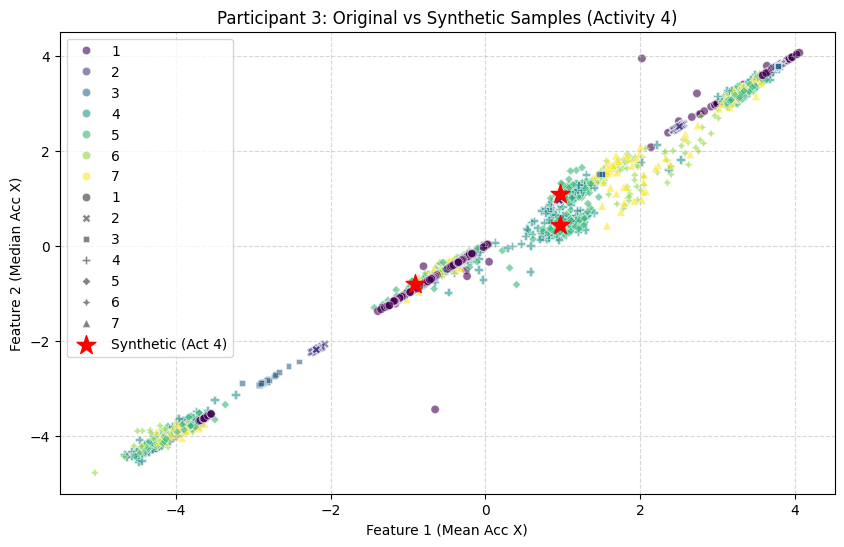

In [46]:
# ==========================================
# 4. Main Execution
# ==========================================

# A. Load & Process
df_raw = load_participant_3()
df_features = generate_features_for_participant(df_raw)

# B. Filter for Meta 2 (Activities 1-7)
df_features = df_features[df_features["Activity"] <= 7]

# C. Prepare Data for SMOTE
# We need X and y
target_act = 4
X = df_features.drop(columns=["Activity"])
y = df_features["Activity"]

# D. Run SMOTE Logic
X_resampled, y_resampled, X_syn = generate_synthetic_samples(X, y, target_act, n_new_samples=3)

# E. Visualization
if X_syn is not None:
    # Use only first two features for 2D plot
    feat_x = X.columns[0]
    feat_y = X.columns[1]
    
    plt.figure(figsize=(10, 6))
    
    # Plot original points
    sns.scatterplot(data=df_features, x=feat_x, y=feat_y, hue="Activity", style="Activity", palette="viridis", alpha=0.6)
    
    # Plot synthetic points
    # We construct a temporary DF for them to plot easily
    plt.scatter(X_syn[feat_x], X_syn[feat_y], color='red', marker='*', s=200, label='Synthetic (Act 4)', zorder=10)
    
    plt.title(f"Participant 3: Original vs Synthetic Samples (Activity {target_act})")
    plt.xlabel("Feature 1 (Mean Acc X)")
    plt.ylabel("Feature 2 (Median Acc X)")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

2.1 Comparing our previous explicit feature extraction vs Embedding features